## Question 2: Classification & Logistic Regression – Employee Attrition or Credit Risk

### Scenario

You are hired by an organization to build a system that predicts a **binary outcome**:

* Whether an **employee will leave** the company, OR
* Whether a **customer will default** on a credit card payment.

### Datasets (Choose ONE)

* **IBM HR Analytics Employee Attrition Dataset**
  [https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset](https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset)

* **Credit Card Default Dataset**
  [https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset](https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset)

### Tasks

1. Justify why **Logistic Regression** is suitable for this problem.
2. Perform full **data preprocessing**:

   * Missing value handling
   * Encoding categorical variables
   * Feature scaling
3. Train a **Logistic Regression** classifier.
4. Evaluate the model using:

   * Confusion Matrix
   * Precision, Recall, F1-score
   * AUC Score
5. Interpret model coefficients using **odds ratios**.
6. Discuss the impact of **class imbalance** and possible solutions.

___
___

About Dataset
Uncover the factors that lead to employee attrition and explore important questions such as ‘show me a breakdown of distance from home by job role and attrition’ or ‘compare average monthly income by education and attrition’. This is a fictional data set created by IBM data scientists.

Education
1 'Below College'
2 'College'
3 'Bachelor'
4 'Master'
5 'Doctor'

EnvironmentSatisfaction
1 'Low'
2 'Medium'
3 'High'
4 'Very High'

JobInvolvement
1 'Low'
2 'Medium'
3 'High'
4 'Very High'

JobSatisfaction
1 'Low'
2 'Medium'
3 'High'
4 'Very High'

PerformanceRating
1 'Low'
2 'Good'
3 'Excellent'
4 'Outstanding'

RelationshipSatisfaction
1 'Low'
2 'Medium'
3 'High'
4 'Very High'

WorkLifeBalance
1 'Bad'
2 'Good'
3 'Better'
4 'Best'

___
___

## Data understanding

In [62]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [63]:
df = pd.read_csv("Employee.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [64]:
df.shape

(1470, 35)

The dataset has 35 columns and 1470 rows of data.

In [65]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

The dataset contains 26 integer data column and 9 string data column.
It was observed that there are no null data in any column of the dataset.

In [66]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


 ### Key observations

 - **Age:** Average age is **36.92**, ranging from **18 to 60**.
- **DailyRate:** Mean = **802.49**, with values from **102 to 1,499**.
- **MonthlyIncome:** Mean = **6,502.93**, ranging from **1,009 to 19,999**.
- **DistanceFromHome:** Average distance is **9.19**, with a median of **7**.
- **JobLevel:** Mean = **2.06**, ranging from **1 to 5**.
- **TotalWorkingYears:** Average experience is **11.28 years**, maximum **40 years**.
- **YearsAtCompany:** Average tenure is **7.01 years**, maximum **40 years**.
- **JobSatisfaction:** Mean = **2.73** on a 1–4 scale.
- **PerformanceRating:** Mean = **3.15**, with only values **3 and 4**.

___
- **EmployeeCount** and **StandardHours** have **zero standard deviation**, meaning they are constant and can generally be removed from analysis.
- **EmployeeNumber** is an identifier rather than a meaningful analytical variable, so it would typically also be excluded from modeling.

___
___

## Visualization

In [67]:
df.select_dtypes(include="number").columns

Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='str')

___
- Employee count, Employee number and standard hours were not taken for visualization.

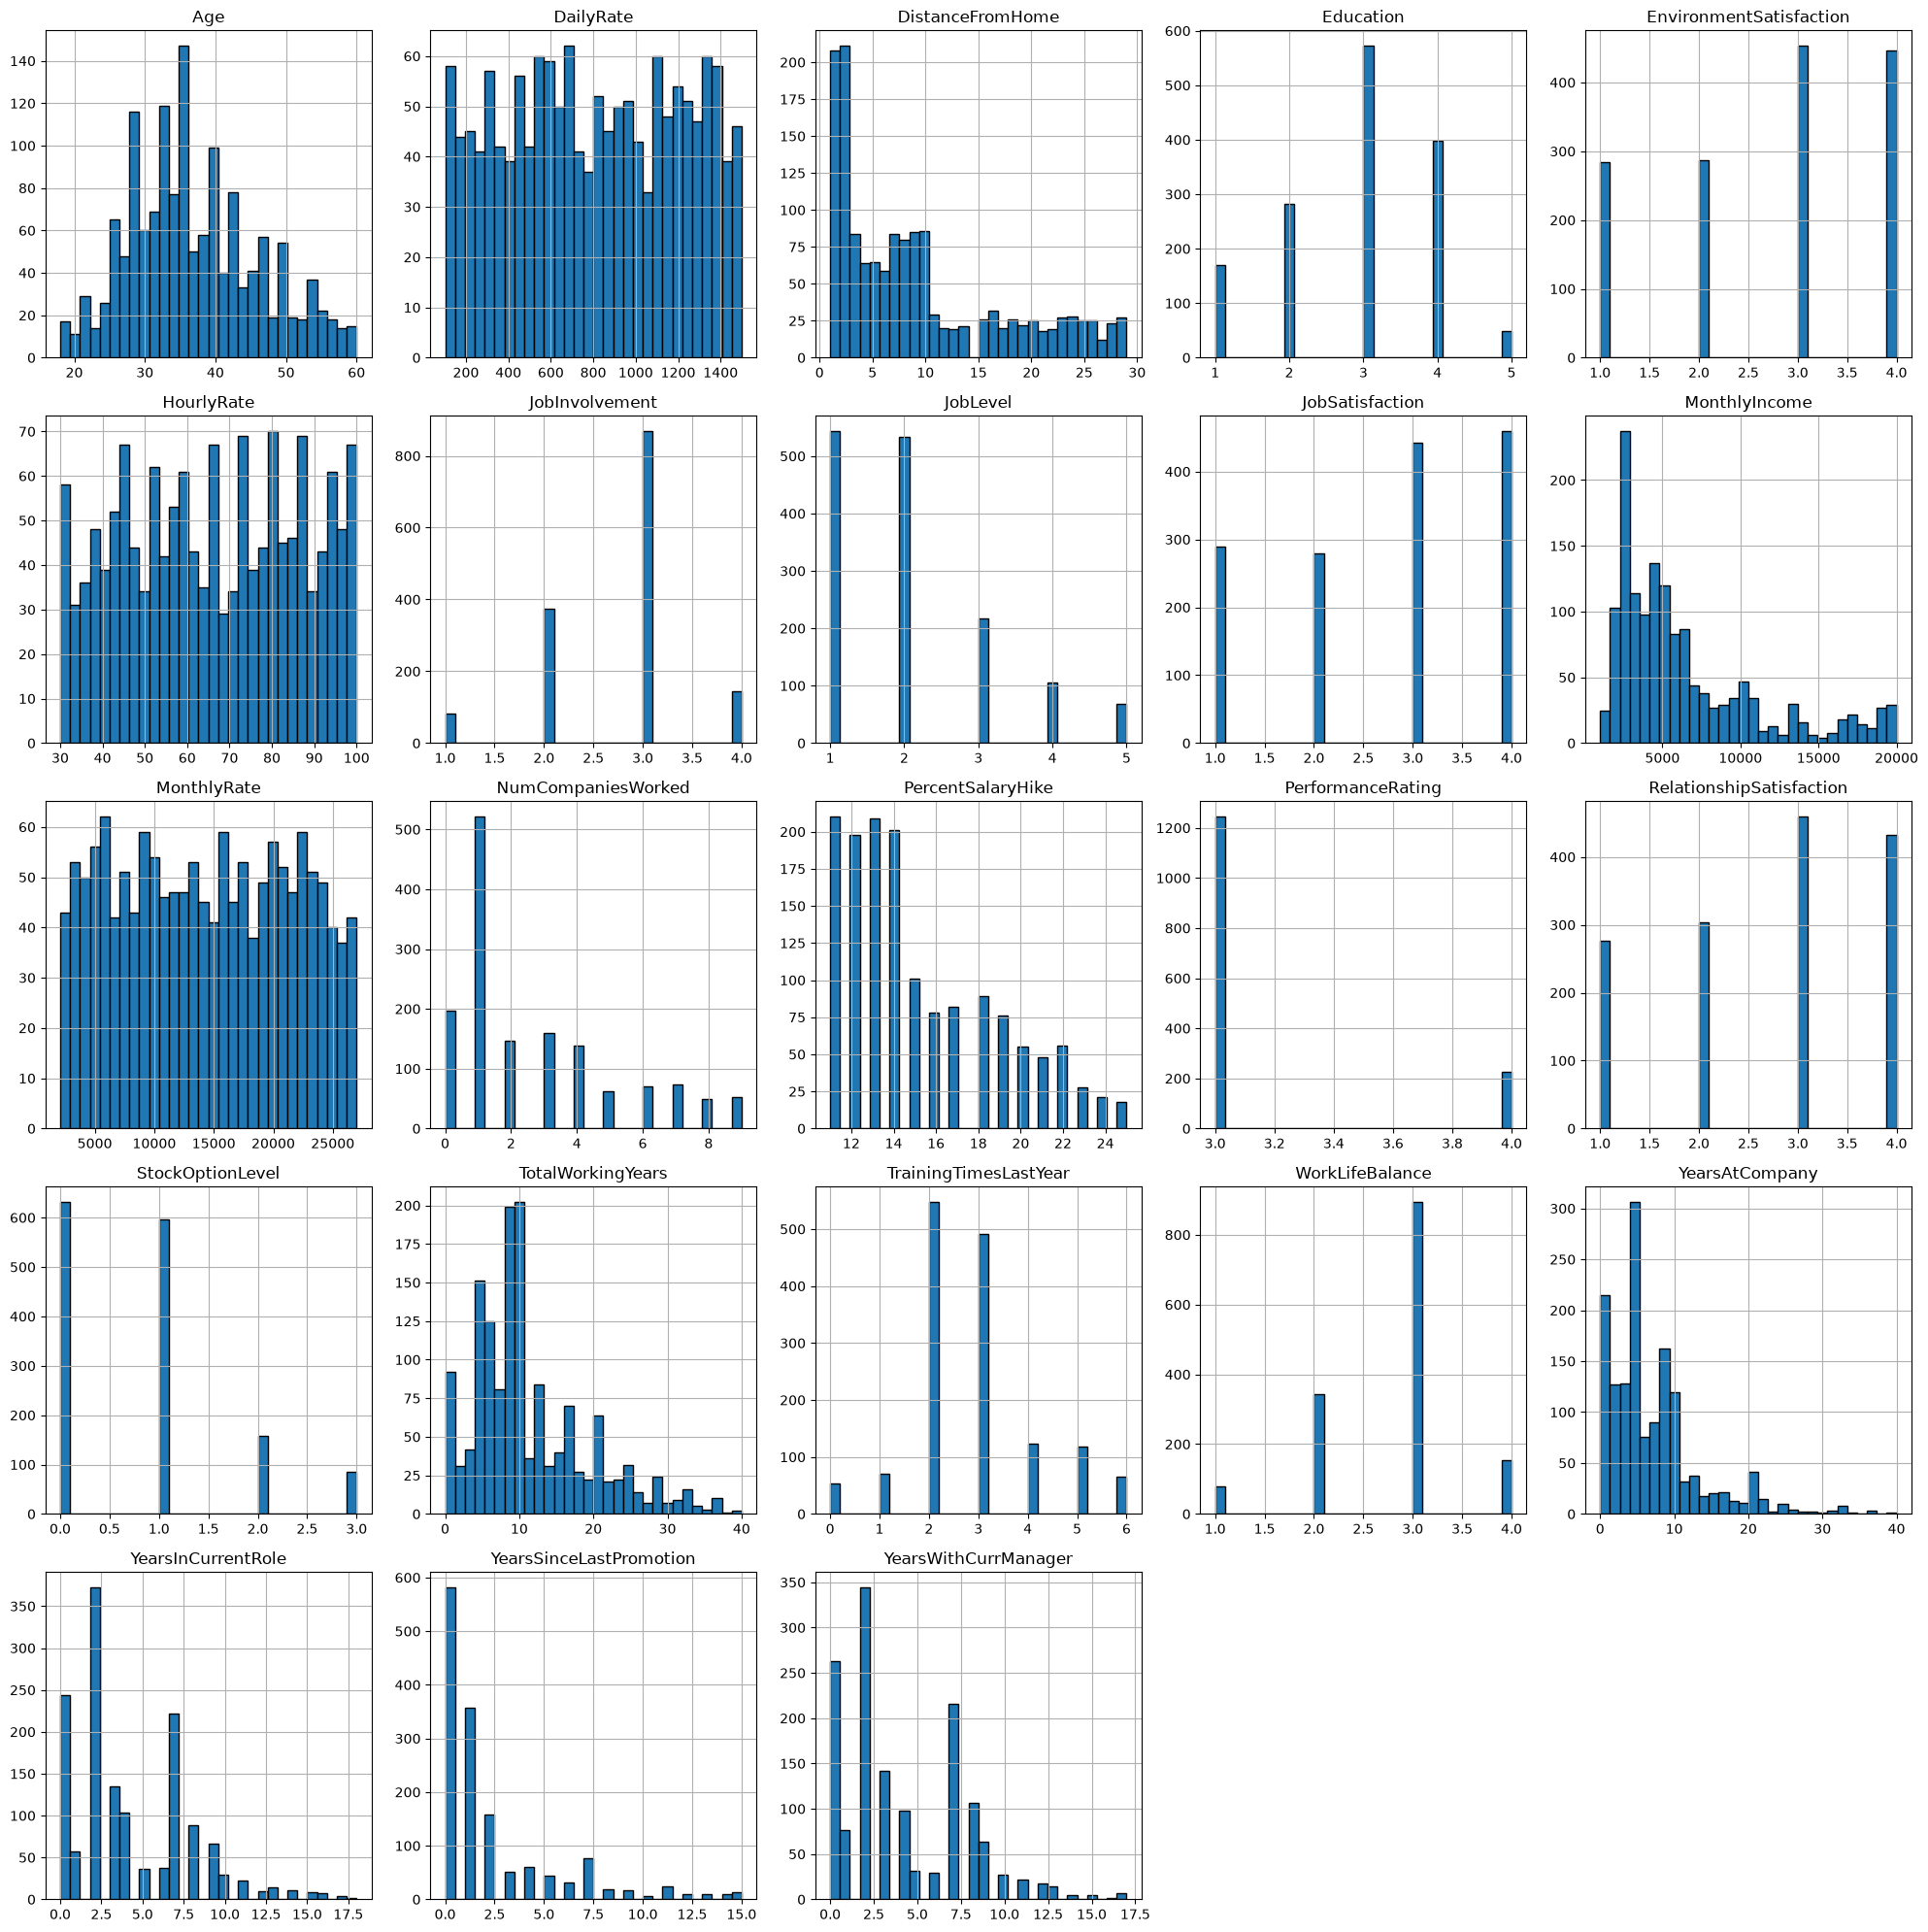

In [68]:
numeric_cols = ['Age', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager']

df[numeric_cols].hist( edgecolor = "black", bins = 30, figsize=(20,20))
plt.tight_layout()
plt.show()

In [69]:
df.select_dtypes(include = {"category", "object"}).columns

C:\Users\bobs9\AppData\Local\Temp\ipykernel_4248\3575370484.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include = {"category", "object"}).columns


Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='str')

___

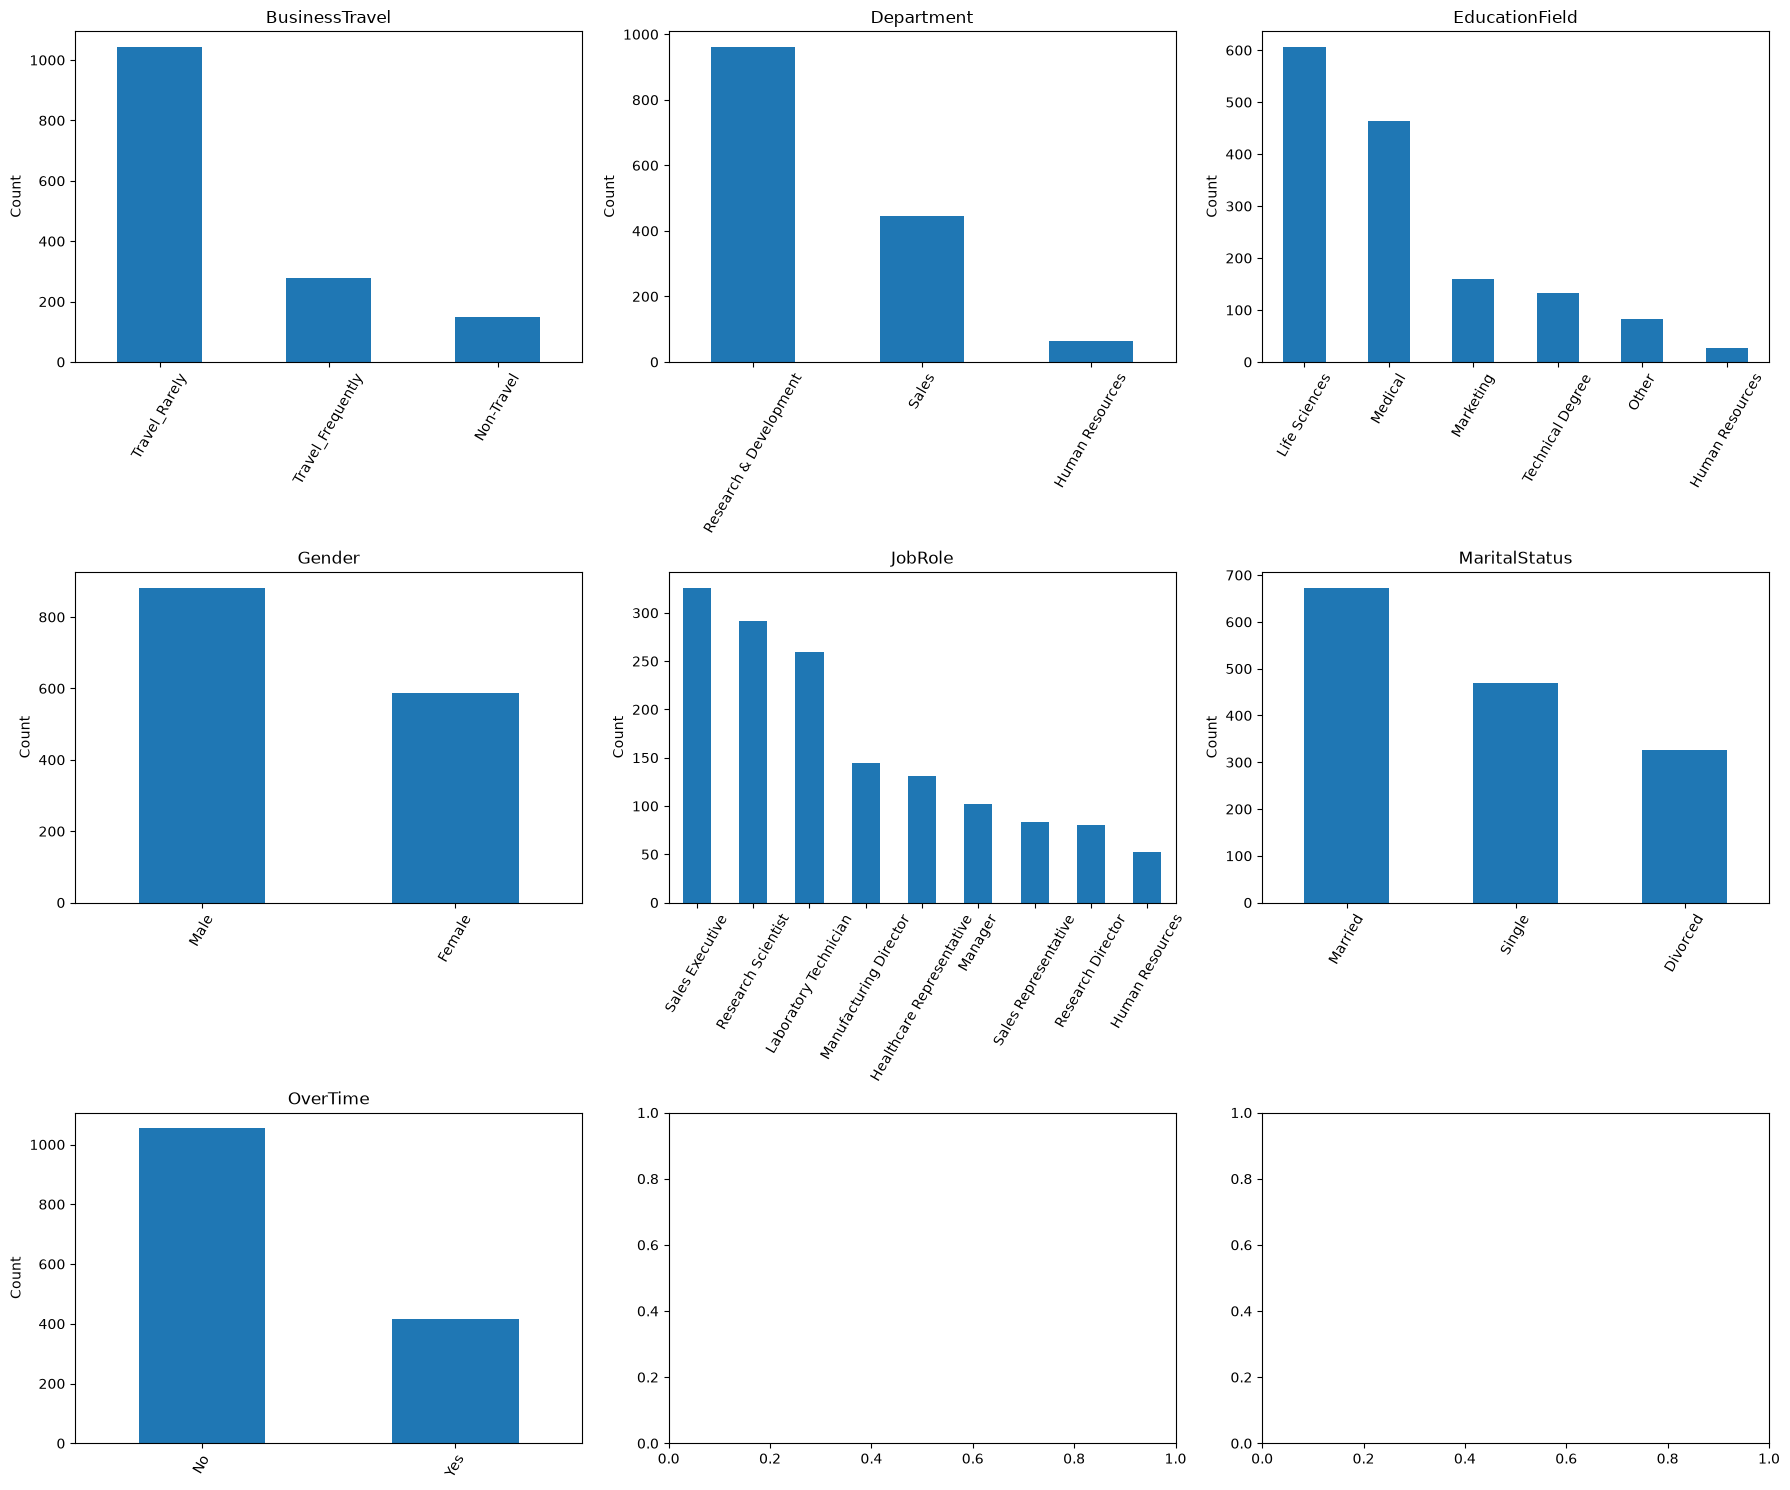

In [70]:
categorical_cols = [ 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'OverTime']

fig, axes = plt.subplots(3, 3, figsize=(18, 15))

for col, ax in zip(categorical_cols, axes.flatten()):
    df[col].value_counts().plot(kind='bar', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=60)

plt.tight_layout()
plt.show()


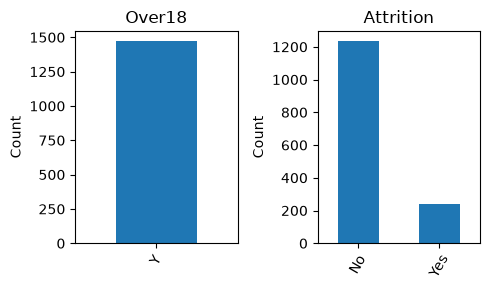

In [71]:
dropable_X_col = [ "Over18", "Attrition"]

fig, axes = plt.subplots(1, 2, figsize=(5, 3))

for col, ax in zip(dropable_X_col, axes.flatten()):
    df[col].value_counts().plot(kind='bar', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=60)

plt.tight_layout()
plt.show()

Over 18 is "yes" for all data thus removed from analysis.

In [72]:
num_df = df[numeric_cols]

<Axes: >

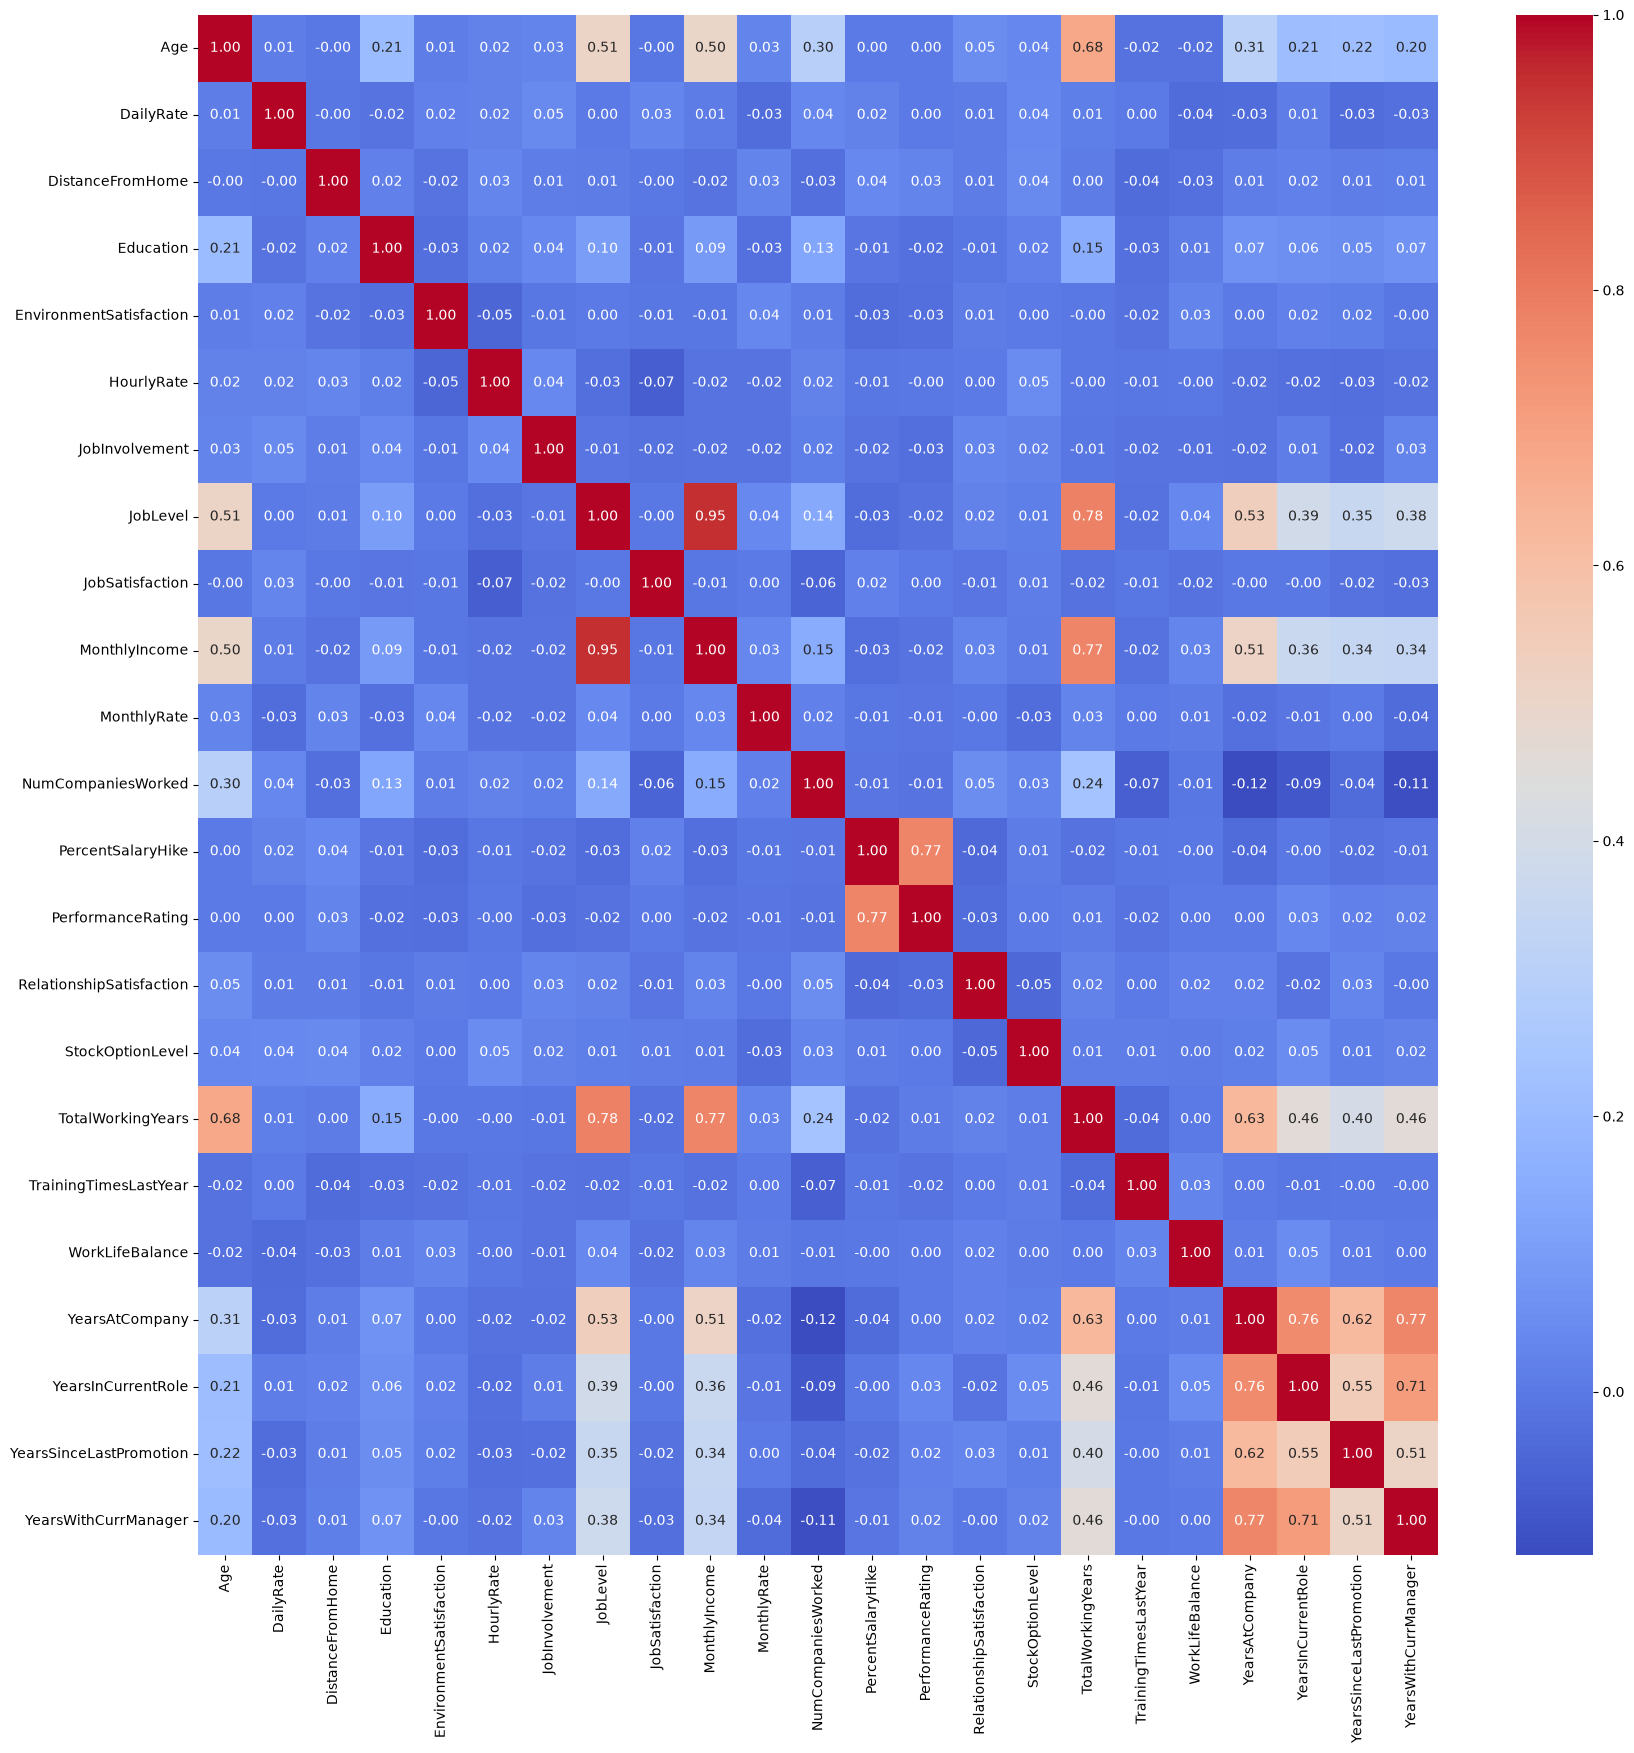

In [73]:
plt.figure(figsize = (20,20))
sns.heatmap(num_df.corr(numeric_only= True), annot = True ,fmt = ".2f" , cmap = "coolwarm")

This heatmap shows pairwise correlations between the variables. Red indicates a stronger positive correlation, while blue indicates a weak or near-zero correlation. The diagonal is 1.00 because each variable is perfectly correlated with itself.

Notable relationships include:

- **JobLevel and MonthlyIncome:** very strong positive correlation (**0.95**).
- **PercentSalaryHike and PerformanceRating:** strong positive correlation (**0.77**).
- **TotalWorkingYears** correlates with **Age (0.68)**, **YearsAtCompany (0.63)**, **MonthlyIncome (0.77)**, and **JobLevel (0.78)**.
- The tenure variables are positively related: **YearsAtCompany and YearsWithManager (0.77)**, **YearsAtCompany and YearsInCurrentRole (0.76)**, and **YearsInCurrentRole and YearsWithManager (0.71)**.
- Most other correlations are close to zero, suggesting weak linear relationships.

Correlation does not imply causation; also, the strong links among income, job level, and tenure may indicate overlapping information in a model.

___

Task 1 :
- Logistic regression is suitable for such case because the the predicted value comes with either yes or no , said the predicted values can be represented in binary 0 and 1.

Task 2:
- There are no missing values.

In [74]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split


# Task 3

In [75]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

model = Pipeline([("preprocessor",preprocessor),
    ("model",LogisticRegression())
])
    

In [96]:
X = df.drop(columns = ['Over18','EmployeeCount',
       'EmployeeNumber','StandardHours','Attrition'])

y = df["Attrition"].map({
    "No": 0,
    "Yes": 1
})

In [97]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size= 0.20 , random_state= 999)

In [98]:
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

# Task 4

In [94]:
from sklearn.metrics import confusion_matrix, precision_score, f1_score, roc_auc_score, recall_score

In [99]:
confusion_matrix(y_test, y_pred)



array([[237,   9],
       [ 28,  20]])

In [100]:
precision_score(y_test, y_pred)

0.6896551724137931

In [101]:
f1_score(y_test, y_pred)

0.5194805194805194

In [ ]:
auc = roc_auc_score(y_test,y_pred)

auc

0.690040650406504

# Task 5

In [106]:
# Get feature names after OneHotEncoder/StandardScaler
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

# Get logistic regression coefficients
coefficients = model.named_steps["model"].coef_[0]

# Calculate odds ratios
odds_ratios = np.exp(coefficients)

# Create table
odds_ratio_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Odds_Ratio": odds_ratios
})

# Sort by odds ratio
odds_ratio_df.sort_values(
    "Odds_Ratio",
    ascending=False
)

,Feature,Coefficient,Odds_Ratio
50,cat__OverTime_Yes,1.000624,2.719979
24,cat__BusinessTravel_Travel_Frequently,0.968021,2.632728
21,num__YearsSinceLastPromotion,0.763314,2.145373
34,cat__EducationField_Technical Degree,0.742891,2.102003
45,cat__JobRole_Sales Representative,0.641031,1.898437
39,cat__JobRole_Laboratory Technician,0.594143,1.811477
48,cat__MaritalStatus_Single,0.539822,1.715701
11,num__NumCompaniesWorked,0.468947,1.598310
2,num__DistanceFromHome,0.412496,1.510584
19,num__YearsAtCompany,0.404622,1.498735


___

In data science, an odds ratio (OR) measures how strongly an outcome is associated with an exposure or group.

1. The table shows how features relate to the model’s predicted outcome, likely employee attrition.
2. Positive coefficients and odds ratios above 1 indicate higher modeled odds.
3. Negative coefficients and odds ratios below 1 indicate lower modeled odds.
4. Overtime (“Yes”) has the strongest positive association (odds ratio ≈ 2.72).
5. Frequent business travel is also strongly associated with higher odds (≈ 2.63).
6. Years since last promotion and certain job roles also show higher odds.
7. Overtime (“No”) has a strong negative association (odds ratio ≈ 0.36).
8. Longer time in the current role and several satisfaction measures are associated with lower odds.
9. Odds ratios describe odds, not direct changes in probability.
10. These are associations, not proof of cause; check feature scaling and statistical significance.


___

## 6. Class Imbalance

Class imbalance occurs when one class has significantly more samples than another. In this dataset, **employees who did not leave (`No`) are much more common than employees who left (`Yes`)**.

Because of this imbalance, the model may become biased toward predicting the majority class (`No`). This can result in missing many actual attrition cases, even if the overall accuracy looks good.

In our model, the confusion matrix shows that **28 actual attrition cases were incorrectly predicted as `No`**, while only 20 were correctly identified as `Yes`. Therefore, accuracy alone is not enough to evaluate the model. Metrics such as **precision, recall, F1-score, and ROC-AUC** should also be considered.

### Possible Solutions

* **Class Weighting:** Use `class_weight="balanced"` in Logistic Regression to give more importance to the minority class.
* **Oversampling:** Use techniques such as **SMOTE** to increase the representation of the minority class.
* **Undersampling:** Reduce the number of samples from the majority class.
* **Threshold Adjustment:** Lower the classification threshold to identify more potential attrition cases and improve recall.

Overall, handling class imbalance can help the model better identify employees who are likely to leave the company.


___
___